# Linear Algebra → Tensors — Python Lab

Python companion to the tutoring course (vault: `00 Linear Algebra MOC`). One section per lesson, same numbering as the vault notes.

**Every lesson:** recap (formulas + mnemonics) → **steps** in code → **Code it yourself** → **exercises** with self-check.

**How to use**
- Run the **Setup** cell first. After that, `Run All` works on a fresh copy — unanswered items just show ⏳.
- Answer by replacing `None`, then re-run the cell → ✅, or ❌ with the expected value.
- **▶ Predict** = write your answer down *before* running the cell.
- Exercise IDs match the course (`E0.x`, `S1.x` … `S5.x`, `P.Qx` = placement test). `N…` and `D1` are new, Python-only practice.

**Requires:** Python ≥ 3.9, `numpy`, `matplotlib`. Optional: `ipywidgets` (sliders in 1a and 2b).

| Lesson | Topic | Vault note |
|---|---|---|
| 0 | Σ and index notation | 01 |
| 1a | Dot product | 02 |
| 1b | Norm, unit vectors, cosine similarity, projection | 03 |
| 2 | Matrices as transformations | 04 |
| 2b | Determinant | 05 |
| 3 | Transpose and the shape game | 06 |
| 4 | Einstein notation → `np.einsum` | 07 |
| 4b | Trace | 08 |
| 5 | Eigenvectors & eigenvalues — *planned* | — |
| 6 | Tensors: physics vs ML — *planned* | — |
| ★ | Mnemonics → NumPy cheat sheet, scoreboard | 09 |

**Sources**
- Deisenroth, Faisal & Ong, *Mathematics for Machine Learning* (MML), Cambridge University Press 2020 — free PDF: https://mml-book.github.io
- 3Blue1Brown, *Essence of Linear Algebra*: https://www.3blue1brown.com/topics/linear-algebra
- G. Strang, MIT 18.06 Linear Algebra: https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/
- D. J. Griffiths, *Introduction to Electrodynamics*, Ch. 1 (index notation, physics side)
- NumPy reference: https://numpy.org/doc/stable/reference/

## Setup

Three NumPy rules that prevent most bugs in this course:

1. **Math is 1-based, NumPy is 0-based.** $M_{23}$ → `M[1, 2]`. Subtract one from each index, never swap them (RC still holds).
2. **`*` keeps the shape, `@` eats the shared axis.** `a * b` is the Hadamard (elementwise) product, `a @ b` the dot / matrix product.
3. **1-D arrays are orientation-blind.** `a.T` does nothing to a 1-D array — make a column explicit with `a[:, None]` when shape matters.

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict   # Counter: counts how often each item occurs; defaultdict: dict that creates missing keys automatically

np.set_printoptions(precision=4, suppress=True)   # print floats with 4 decimals; suppress=True shows tiny values like 1e-17 as 0
rng = np.random.default_rng(42)          # fixed seed → same random numbers on every run
print("numpy", np.__version__)

# ── self-check ──────────────────────────────────────────────────────────────
RESULTS = {}

def _show(x):
    if isinstance(x, np.ndarray):
        return np.array2string(x, precision=4, suppress_small=True)   # array → string, formatted like print() shows it
    if isinstance(x, np.generic):
        return repr(x.item())   # .item(): NumPy scalar → plain Python number
    return repr(x)

def check(label, yours, truth, tol=1e-6):
    """Compare your answer with the truth computed by NumPy. Never raises → 'Run All' always works."""
    if yours is None:
        RESULTS[label] = None
        print(f"⏳ {label}: not answered yet")
        return
    try:
        if isinstance(truth, str):
            ok = str(yours).replace(" ", "").lower() == truth.replace(" ", "").lower()
        elif isinstance(truth, (bool, np.bool_)):
            ok = isinstance(yours, (bool, np.bool_)) and bool(yours) == bool(truth)
        elif isinstance(truth, tuple):                                   # shapes
            ok = tuple(int(n) for n in yours) == tuple(int(n) for n in truth)
        else:
            y, t = np.asarray(yours, dtype=float), np.asarray(truth, dtype=float)   # asarray: turn lists / tuples / numbers into an array (no copy if it already is one)
            ok = y.shape == t.shape and np.allclose(y, t, atol=tol)   # allclose: all entries equal up to rounding error (never use == on floats)
    except Exception:
        ok = False
    RESULTS[label] = ok
    print(f"✅ {label}" if ok else f"❌ {label}: you gave {_show(yours)}, expected {_show(truth)}")

def test(fn, cases):
    """Run your implementation on (args, expected) cases and compare with NumPy."""
    name = fn.__name__
    for args, expected in cases:
        try:
            got = fn(*args)
            if got is None:
                RESULTS[f"code:{name}"] = None
                print(f"⏳ {name}: not implemented yet")
                return
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
            ok = g.shape == e.shape and np.allclose(g, e)
        except Exception as err:
            RESULTS[f"code:{name}"] = False
            print(f"💥 {name}: {type(err).__name__}: {err}")
            return
        if not ok:
            RESULTS[f"code:{name}"] = False
            print(f"❌ {name}: got {_show(np.asarray(got))}, expected {_show(np.asarray(expected))}")
            return
    RESULTS[f"code:{name}"] = True
    print(f"✅ {name}: {len(cases)}/{len(cases)} tests passed")

def run_spec(spec, *operands):
    """Evaluate an einsum spec you wrote. None if unanswered, an error message if invalid."""
    if spec is None:
        return None
    try:
        return np.einsum(spec, *operands)   # Einstein summation from a spec string → Lesson 4
    except Exception as err:
        return f"invalid spec ({err})"

# ── geometry helpers ────────────────────────────────────────────────────────
def polar(r, deg):
    """2-D vector of length r at angle deg (counter-clockwise from the x-axis)."""
    t = np.radians(deg)                  # degrees → radians (np.cos / np.sin expect radians)
    return r * np.array([np.cos(t), np.sin(t)])

def rot2(deg):
    """2-D rotation matrix, counter-clockwise by deg degrees."""
    t = np.radians(deg)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])

def rotation_3d(axis, deg):
    """3-D rotation by deg about an axis (Rodrigues' formula — a black box for now)."""
    k = np.asarray(axis, dtype=float) / np.linalg.norm(axis)   # linalg.norm: length of the vector → k is a unit vector
    K = np.array([[0, -k[2], k[1]], [k[2], 0, -k[0]], [-k[1], k[0], 0]])
    t = np.radians(deg)
    return np.eye(3) + np.sin(t) * K + (1 - np.cos(t)) * (K @ K)   # eye(3): 3×3 identity matrix

def polygon_area(P):
    """Area of a polygon given as a 2×N array of corner points (shoelace formula)."""
    x, y = np.asarray(P, dtype=float)
    # roll(y, -1): shift entries one to the left, wrapping around → coordinates of the NEXT corner
    return 0.5 * abs(np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y))

def arrows(vectors, labels=None, colors=None, ax=None, lim=None, title=None):
    """Draw 2-D vectors as arrows from the origin."""
    vecs = [np.asarray(v, dtype=float) for v in vectors]
    colors = colors or [f"C{i}" for i in range(len(vecs))]
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))    # new figure + one axes to draw on; figsize in inches
    for i, v in enumerate(vecs):
        # annotate with empty text + arrowprops = just an arrow from xytext to xy
        ax.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", lw=2, color=colors[i]))
        if labels:
            ax.text(*(v * 1.1 + 0.05), labels[i], color=colors[i], fontsize=11)
    m = lim or 1.25 * max(1.0, max(np.abs(v).max() for v in vecs))
    ax.set_xlim(-m, m); ax.set_ylim(-m, m); ax.set_aspect("equal")
    ax.axhline(0, color="0.75", lw=0.8); ax.axvline(0, color="0.75", lw=0.8)   # horizontal / vertical line through 0 (the axes); color "0.75" = light grey
    ax.grid(alpha=0.3)
    if title:
        ax.set_title(title, fontsize=10)
    return ax

def show_transform(M, ax=None, title=None, lim=3):
    """Grid + unit square before (grey) and after (blue grid) applying M.
    Green arrow = where î lands (column 1), red arrow = where ĵ lands (column 2).
    Fill: blue = orientation kept (det > 0), orange = flipped (det < 0), grey = crushed (det = 0)."""
    M = np.asarray(M, dtype=float)
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    s = np.linspace(-lim, lim, 60)   # linspace: 60 evenly spaced numbers from -lim to lim (both ends included)
    for t in range(-lim, lim + 1):
        # full_like(s, t): array shaped like s, every entry = t; vstack: stack rows → 2×60 (x-row, y-row)
        for line in (np.vstack([s, np.full_like(s, t)]), np.vstack([np.full_like(s, t), s])):
            ax.plot(*line, color="0.88", lw=0.6)
            ax.plot(*(M @ line), color="C0", lw=0.6, alpha=0.45)
    square = M @ np.array([[0, 1, 1, 0], [0, 0, 1, 1]], dtype=float)
    d = np.linalg.det(M)   # determinant → Lesson 3
    # fill: filled polygon through the corners; isclose: == up to rounding error
    ax.fill(*square, color="0.5" if np.isclose(d, 0) else ("C0" if d > 0 else "C1"), alpha=0.35)
    for vec, col in ((M[:, 0], "tab:green"), (M[:, 1], "tab:red")):
        ax.annotate("", xy=vec, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", lw=2.5, color=col))
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title if title is not None else f"det = {d:+.2f}", fontsize=10)
    return ax

def interactive(fn, **params):
    """Sliders via ipywidgets if installed, else one static call with the defaults.
    params: name=(min, max, step, default)"""
    defaults = {k: v[3] for k, v in params.items()}
    try:
        from ipywidgets import interact, FloatSlider
    except ImportError:
        print("ipywidgets not installed → static version with defaults (pip install ipywidgets for sliders)")
        fn(**defaults)
        return
    interact(fn, **{k: FloatSlider(min=lo, max=hi, step=st, value=d, continuous_update=False)
                    for k, (lo, hi, st, d) in params.items()})

print("helpers ready")

numpy 2.5.3
helpers ready


---
## Lesson 0 — Σ and index notation
*Vault: `01 Sigma and Index Notation` · MML §2.2 · Griffiths Ch. 1*

$$\sum_{i=1}^{n} a_i = a_1 + a_2 + \dots + a_n \qquad\qquad (AB)_{ij} = \sum_{k} A_{ik}B_{kj}$$

- **Σ is a for-loop** with a running total.
- **RC — Row Comes first:** $M_{ij}$ = row $i$, column $j$.
- **Free** indices survive (they are the output's shape). **Dummy** indices are summed away.

### Step 0.1 — Σ is a for-loop

In [78]:
a = np.array([2, 3, 4])

total = 0
for i in range(len(a)):          # math: i = 1..3  →  Python: i = 0..2
    total += a[i]

print(total, sum(a), a.sum())    # three spellings, one number

9 9 9


### Step 0.2 — RC, and the off-by-one
Each entry encodes its own position (`23` = row 2, column 3).

In [79]:
M = np.array([[11, 12, 13, 14],
              [21, 22, 23, 24],
              [31, 32, 33, 34]])

print("shape:", M.shape, "→ (rows, cols)")
print("M_23 in math → M[1, 2] in NumPy =", M[1, 2])
print("row 2   :", M[1, :])
print("column 3:", M[:, 2])

shape: (3, 4) → (rows, cols)
M_23 in math → M[1, 2] in NumPy = 23
row 2   : [21 22 23 24]
column 3: [13 23 33]


### Step 0.3 — A dummy index is a loop variable: its name is irrelevant

In [80]:
a, b = np.array([1, 2, 3]), np.array([4, 5, 6])
print(sum(a[i] * b[i] for i in range(3)), sum(a[k] * b[k] for k in range(3)))

32 32


### Step 0.4 — Matrix product straight from the formula
$(AB)_{ij} = \sum_k A_{ik}B_{kj}$: free $i, j$ → the two outer loops; dummy $k$ → the inner, accumulating loop.

In [83]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])          # 2×3
B = np.array([[7, 8],
              [9, 10],
              [11, 12]])           # 3×2

print("Shapes of A and B: ", A.shape, B.shape)
C = np.zeros((A.shape[0], B.shape[1]))   # zeros(shape): array of that shape  (outer matrix dims) filled with 0.0 — the loops below fill it in
print("Shape of C (outer dims of A and B): ", C.shape)
for i in range(A.shape[0]):            # free
    for j in range(B.shape[1]):        # free
        for k in range(A.shape[1]):    # dummy → summed away
            C[i, j] += A[i, k] * B[k, j]

print(C)
print("Now A @ B: ", A @ B)
print("same as A @ B:", np.allclose(C, A @ B))   # allclose: all entries equal up to rounding error
print("(2×3)(3×2) →", C.shape, "— k ran over 3 values and vanished")

Shapes of A and B:  (2, 3) (3, 2)
Shape of C (outer dims of A and B):  (2, 2)
[[ 58.  64.]
 [139. 154.]]
Now A @ B:  [[ 58  64]
 [139 154]]
same as A @ B: True
(2×3)(3×2) → (2, 2) — k ran over 3 values and vanished


### Step 0.5 — Every entry of $AB$ is a dot product
$(AB)_{21}$ = row 2 of $A$ · column 1 of $B$. **Matrix multiplication is a grid of dot products.**

In [84]:
print((A @ B)[1, 0], "==", A[1, :] @ B[:, 0])

139 == 139


### Step 0.6 — Constants factor out: $\sum_i c\,x_i = c\sum_i x_i$

In [85]:
x = rng.integers(-5, 6, size=4)   # 4 random integers from -5 to 5 (the upper bound 6 is excluded)
c = 3
print(sum(c * x[i] for i in range(4)), "==", c * x.sum())

-3 == -3


### Code it yourself — `my_matmul`
Loops only: no `@`, `np.dot`, `np.matmul`.

In [14]:
def my_matmul(A, B):
    # TODO: (AB)_ij = Σ_k A_ik B_kj — three loops, return a NumPy array
    return None

A0 = np.array([[1, 2, 3], [4, 5, 6]])
B0 = np.array([[7, 8], [9, 10], [11, 12]])
R1, R2 = rng.normal(size=(3, 4)), rng.normal(size=(4, 2))   # random matrices of the given shape (entries from a normal distribution)
test(my_matmul, [((A0, B0), A0 @ B0), ((B0, A0), B0 @ A0), ((R1, R2), R1 @ R2)])

⏳ my_matmul: not implemented yet


<details><summary><b>Reference solution</b></summary>

```python
def my_matmul(A, B):
    m, n = A.shape
    n2, p = B.shape
    assert n == n2, "inner dimensions must match"
    C = np.zeros((m, p))
    for i in range(m):
        for j in range(p):
            for k in range(n):
                C[i, j] += A[i, k] * B[k, j]
    return C
```

</details>

### Exercises — Set 0
**E0.3** Expand $\sum_{k=1}^{3} A_{2k}B_{k1}$ for the $A, B$ below — as a Python expression with 0-based indices: `A[?, ?] * B[?, ?] + …`

**E0.4** Which entry of $AB$ is that? $(i, j)$ in **math** numbering.

**E0.5** Is $\sum_{i=1}^{3} a_i b_j$ fully specified? `True` / `False`

**E0.7** $c = 3x_1 + 3x_2 + 3x_3 + 3x_4 = 3\sum_{i=1}^{n} x_i$. What is $n$?

In [15]:
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([[7, 8], [9, 10], [11, 12]])

E0_3 = None     # expression with A[., .] and B[., .]
E0_4 = None     # tuple (i, j)
E0_5 = None     # True / False
E0_7 = None     # integer

check("E0.3", E0_3, sum(A[1, k] * B[k, 0] for k in range(3)))
check("E0.4", E0_4, (2, 1))
check("E0.5", E0_5, False)
check("E0.7", E0_7, 4)

⏳ E0.3: not answered yet
⏳ E0.4: not answered yet
⏳ E0.5: not answered yet
⏳ E0.7: not answered yet


Why E0.5 is `False` — run after answering:

In [16]:
a, b = np.array([1, 2, 3]), np.array([4, 5, 6])
for j in range(3):      # j is never bound → a different number for every j: it names a vector, not a number
    print(f"j = {j + 1}:", sum(a[i] * b[j] for i in range(3)))

j = 1: 24
j = 2: 30
j = 3: 36


---
## Lesson 1a — The dot product
*Vault: `02 Dot Product` · MML §3.2, §3.4 · 3Blue1Brown Ch. 9*

$$a\cdot b = \sum_i a_i b_i = \lVert a\rVert\,\lVert b\rVert\cos\theta \qquad\qquad a\odot b = (a_1b_1,\ a_2b_2,\ \dots)$$

- **The dot is a full stop** → one number (the *scalar* product). $\odot$ (Hadamard) keeps a vector.
- **Number line, not a switch:** −1 opposed … 0 unrelated … +1 aligned. Zero is the *middle*.
- **Same sign, same side** of the perpendicular "fence".

### Step 1a.1 — Hadamard vs dot (the placement-test trap)

In [17]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("a * b      =", a * b, "  ← Hadamard: vector out")
print("a @ b      =", a @ b, "          ← dot: scalar out")
print("np.dot     =", np.dot(a, b))
print("sum(a * b) =", np.sum(a * b), "          ← dot = Hadamard, then Σ collapses it")

a * b      = [ 4 10 18]   ← Hadamard: vector out
a @ b      = 32           ← dot: scalar out
np.dot     = 32
sum(a * b) = 32           ← dot = Hadamard, then Σ collapses it


### Step 1a.2 — Algebra and geometry give the same number
`u`, `v` are *built* from lengths 2 and 3, 55° apart. The component sum doesn't know that.

In [18]:
u, v = polar(2, 20), polar(3, 75)
print("Σ u_i v_i       =", u @ v)
print("|u| |v| cos 55° =", 2 * 3 * np.cos(np.radians(55)))   # radians: degrees → radians (np.cos / np.sin expect radians)

Σ u_i v_i       = 3.4414586181062763
|u| |v| cos 55° = 3.441458618106277


### Step 1a.3 — The sign is the sign of cos θ
▶ **Predict** the label for each angle, then run.

θ =   0°   a·b = +1.000   agree
θ =  45°   a·b = +0.707   agree
θ =  89°   a·b = +0.017   agree
θ =  90°   a·b = +0.000   indifferent (⟂)
θ =  91°   a·b = -0.017   disagree
θ = 135°   a·b = -0.707   disagree
θ = 180°   a·b = -1.000   disagree


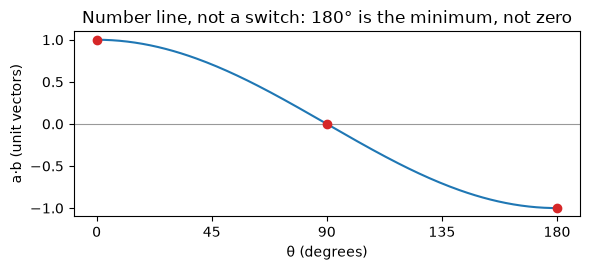

In [19]:
e = polar(1, 0)
for deg in (0, 45, 89, 90, 91, 135, 180):
    d = e @ polar(1, deg)
    label = "agree" if d > 1e-12 else "disagree" if d < -1e-12 else "indifferent (⟂)"
    print(f"θ = {deg:>3}°   a·b = {d:+.3f}   {label}")

degs = np.arange(0, 181)   # arange: 0, 1, …, 180 (end excluded, like range)
plt.figure(figsize=(6, 2.8))
plt.plot(degs, np.cos(np.radians(degs)))
plt.axhline(0, color="0.6", lw=0.8)   # horizontal line at y = 0
plt.scatter([0, 90, 180], [1, 0, -1], color="C3", zorder=3)   # dots at (x, y) pairs; zorder=3 draws them on top of the line
plt.xticks([0, 45, 90, 135, 180]); plt.xlabel("θ (degrees)"); plt.ylabel("a·b (unit vectors)")
plt.title("Number line, not a switch: 180° is the minimum, not zero")
plt.tight_layout(); plt.show()   # tight_layout: shrink margins so labels don't overlap

### Step 1a.4 — Antiparallel is *not* zero (your former blind spot)

In [20]:
p, q = np.array([1, 1]), np.array([-2, -2])
print("p·q =", p @ q, "   q = −2p:", np.allclose(q, -2 * p), "→ θ = 180°, maximally negative")

p·q = -4    q = −2p: True → θ = 180°, maximally negative


### Step 1a.5 — See it (sliders if `ipywidgets` is installed)
Orange bar = the *shadow* of b on a's direction; its signed length is $a\cdot b/\lVert a\rVert$.

In [21]:
def dot_demo(theta=120.0):
    a, b = polar(2, 0), polar(1.5, theta)
    d = a @ b
    ax = arrows([a, b], labels=["a", "b"], lim=2.5, title=f"θ = {theta:.0f}°    a·b = {d:+.2f}")
    ax.plot([0, d / 2], [0, 0], color="C1", lw=7, alpha=0.4)      # shadow of b on a (|a| = 2)
    plt.show()

interactive(dot_demo, theta=(0, 180, 1, 120))

interactive(children=(FloatSlider(value=120.0, continuous_update=False, description='theta', max=180.0, step=1…

### Step 1a.6 — Where it shows up
**Physics:** work $W = \vec F\cdot\vec d$. **ML:** attention scores $QK^\top$ — a grid of query·key dot products.

In [22]:
F = np.array([0.0, 20.0])       # N — holding a bag up against gravity
d = np.array([5.0, 0.0])        # m — walking horizontally
print("work carrying the bag:", F @ d, "J  (force ⟂ motion → no work)")
print("work lifting it 0.5 m:", F @ np.array([0.0, 0.5]), "J")

Q = rng.normal(size=(3, 4))     # 3 query tokens × 4 features
K = rng.normal(size=(3, 4))     # 3 key tokens   × 4 features
scores = Q @ K.T                # (3×4)(4×3) → 3×3;  .T = transpose (Lesson 3)
print("attention scores:\n", scores)
print("scores[0, 2] is q₀·k₂:", np.isclose(scores[0, 2], Q[0] @ K[2]))   # isclose: == up to rounding error (allclose for single numbers)

work carrying the bag: 0.0 J  (force ⟂ motion → no work)
work lifting it 0.5 m: 10.0 J
attention scores:
 [[ 0.9233 -1.6181 -0.9765]
 [ 0.3315  0.3396 -0.127 ]
 [ 1.6024 -2.8529 -1.7574]]
scores[0, 2] is q₀·k₂: True


### Code it yourself — `my_dot`, `my_hadamard`

In [23]:
def my_dot(a, b):
    # TODO: loop and accumulate a[i] * b[i] → return ONE number
    return None

def my_hadamard(a, b):
    # TODO: return a NEW array whose slot i holds a[i] * b[i]
    return None

a1, b1 = np.array([1, 2, 3]), np.array([4, 5, 6])
x5, y5 = rng.normal(size=5), rng.normal(size=5)
test(my_dot, [((a1, b1), a1 @ b1), ((x5, y5), x5 @ y5)])
test(my_hadamard, [((a1, b1), a1 * b1), ((x5, y5), x5 * y5)])

⏳ my_dot: not implemented yet
⏳ my_hadamard: not implemented yet


<details><summary><b>Reference solution</b></summary>

```python
def my_dot(a, b):
    total = 0.0
    for i in range(len(a)):
        total += a[i] * b[i]
    return total

def my_hadamard(a, b):
    return np.array([a[i] * b[i] for i in range(len(a))])
```

</details>

### Exercises
**P.Q1** (placement) $a\cdot b$ for $a=(1,2,3)$, $b=(4,5,6)$.

**D1** (new drill) ▶ Sign of each dot product **without computing** — one character per pair from `+`, `0`, `-`.

In [24]:
P_Q1 = None
check("P.Q1", P_Q1, np.array([1, 2, 3]) @ np.array([4, 5, 6]))

pairs = [((1, 0), (0, 1)),
         ((1, 1), (-2, -2)),
         ((3, 1), (1, 2)),
         ((2, -1), (1, 2)),
         ((0, 0, 5), (0, 0, -5)),
         ((1, 2, 3), (-1, -1, 1)),
         ((1, -1), (-3, 2))]
D1 = None       # string of 7 characters
# sign: +1 / 0 / -1 for positive / zero / negative
truth = "".join({1: "+", 0: "0", -1: "-"}[int(np.sign(np.dot(x, y)))] for x, y in pairs)
check("D1", D1, truth)

⏳ P.Q1: not answered yet
⏳ D1: not answered yet


---
## Lesson 1b — Norm, unit vectors, cosine similarity, projection
*Vault: `03 Norm and Cosine Similarity` · MML §3.1, §3.4, §3.8*

$$\lVert a\rVert = \sqrt{a\cdot a} \qquad \hat a = \frac{a}{\lVert a\rVert} \qquad \cos\theta = \frac{a\cdot b}{\lVert a\rVert\,\lVert b\rVert} = \hat a\cdot\hat b \qquad \operatorname{proj}_a b = \frac{a\cdot b}{a\cdot a}\,a$$

- **The hat means "length one"** — free safety net: $\lVert\hat a\rVert$ must be 1.
- **Cosine asks "which way?", never "how much?"**
- **Projection: measure, normalize, re-point.**

### Step 1b.1 — Norm, three ways (Pythagoras in n dimensions)

In [25]:
a = np.array([3.0, 4.0])
print(np.sqrt(a @ a), np.sqrt(np.sum(a**2)), np.linalg.norm(a))   # linalg.norm = length ‖a‖

5.0 5.0 5.0


### Step 1b.2 — Unit vector + the safety net

In [26]:
a_hat = a / np.linalg.norm(a)
print("â =", a_hat, "   ‖â‖ =", np.linalg.norm(a_hat))
assert np.isclose(np.linalg.norm(a_hat), 1.0), "safety net: ‖â‖ ≠ 1 → arithmetic slip"

â = [0.6 0.8]    ‖â‖ = 1.0


### Step 1b.3 — Cosine similarity ignores magnitude
▶ **Predict:** which document does the raw dot product rank first? Which does cosine?

In [27]:
def cos_sim(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("(1,1) vs (100,100):", cos_sim(np.array([1, 1]), np.array([100, 100])), "— scaling never rotates")

query = np.array([1.0, 2.0, 0.0])
docs = {"doc_A (same direction, small)": np.array([0.5, 1.0, 0.0]),
        "doc_B (other direction, huge)": np.array([10.0, 0.0, 5.0])}
for name, doc in docs.items():
    print(f"{name:32s} dot = {query @ doc:6.2f}   cosine = {cos_sim(query, doc):.2f}")

(1,1) vs (100,100): 0.9999999999999999 — scaling never rotates
doc_A (same direction, small)    dot =   2.50   cosine = 1.00
doc_B (other direction, huge)    dot =  10.00   cosine = 0.40


Raw dot rewards magnitude (attention's $QK^\top$ wants that); cosine strips it (embedding search usually wants that).

### Step 1b.4 — Projection: measure, normalize, re-point

proj_a b = [3. 0.]    residual = [0. 4.]    residual·a = 0.0 → perpendicular


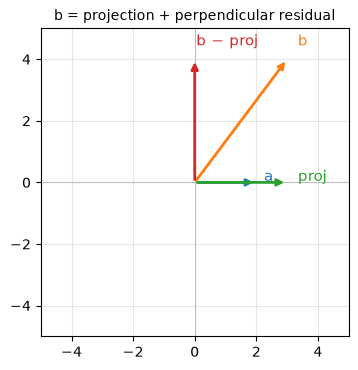

In [28]:
def proj(a, b):
    return (a @ b) / (a @ a) * a         # measure → normalize → re-point

a, b = np.array([2.0, 0.0]), np.array([3.0, 4.0])
p = proj(a, b)
r = b - p
print("proj_a b =", p, "   residual =", r, "   residual·a =", r @ a, "→ perpendicular")
arrows([a, b, p, r], labels=["a", "b", "proj", "b − proj"], lim=5, title="b = projection + perpendicular residual")
plt.show()

### Code it yourself — `my_norm`, `my_proj`

In [29]:
def my_norm(a):
    # TODO: √(Σ a_i²) — a loop and ** 0.5, no np.linalg
    return None

def my_proj(a, b):
    # TODO: projection of b onto a — only @ and arithmetic
    return None

v3, w3 = rng.normal(size=3), rng.normal(size=3)
test(my_norm, [((np.array([3.0, 4.0]),), 5.0), ((v3,), np.linalg.norm(v3))])
test(my_proj, [((np.array([2.0, 0.0]), np.array([3.0, 4.0])), np.array([3.0, 0.0])),
               ((v3, w3), (v3 @ w3) / (v3 @ v3) * v3)])

⏳ my_norm: not implemented yet
⏳ my_proj: not implemented yet


<details><summary><b>Reference solution</b></summary>

```python
def my_norm(a):
    return sum(x * x for x in a) ** 0.5

def my_proj(a, b):
    return (a @ b) / (a @ a) * a
```

</details>

### Exercises
**S1.3** $w=(0,0,5)$, $z=(0,0,-5)$: $w\cdot z$ and the angle in degrees.

**S1.4** $a=(1,0)$, $b=(1,1)$: $\cos\theta$ and the angle in degrees.

**N1b.1** (new) Unit vector of $v=(3,4)$.

**N1b.2** (new) $\operatorname{proj}_a b$ for $a=(1,1,0)$, $b=(2,3,4)$.

In [30]:
S1_3_dot = None
S1_3_angle = None
S1_4_cos = None
S1_4_angle = None
N1b_1 = None        # vector [x, y]
N1b_2 = None        # vector [x, y, z]

_cos = lambda x, y: (x @ y) / (np.linalg.norm(x) * np.linalg.norm(y))
w, z = np.array([0, 0, 5]), np.array([0, 0, -5])
check("S1.3 dot", S1_3_dot, w @ z)
check("S1.3 angle", S1_3_angle, np.degrees(np.arccos(_cos(w, z))))   # arccos: cos θ → θ in radians; degrees: radians → degrees
a, b = np.array([1, 0]), np.array([1, 1])
check("S1.4 cos", S1_4_cos, _cos(a, b), tol=1e-3)
check("S1.4 angle", S1_4_angle, np.degrees(np.arccos(_cos(a, b))), tol=1e-3)
v = np.array([3.0, 4.0])
check("N1b.1", N1b_1, v / np.linalg.norm(v))
a3, b3 = np.array([1.0, 1.0, 0.0]), np.array([2.0, 3.0, 4.0])
check("N1b.2", N1b_2, (a3 @ b3) / (a3 @ a3) * a3)

⏳ S1.3 dot: not answered yet
⏳ S1.3 angle: not answered yet
⏳ S1.4 cos: not answered yet
⏳ S1.4 angle: not answered yet
⏳ N1b.1: not answered yet
⏳ N1b.2: not answered yet


---
## Lesson 2 — A matrix is a transformation
*Vault: `04 Matrices as Transformations` · 3Blue1Brown Ch. 3–4 · MML §2.2, §2.7*

$$\begin{pmatrix} a & b \\ c & d \end{pmatrix}\begin{pmatrix} x \\ y \end{pmatrix} = x\begin{pmatrix} a \\ c \end{pmatrix} + y\begin{pmatrix} b \\ d \end{pmatrix}$$

- **The columns are where the basis vectors land.** A matrix is a record of what happened to the axes.
- **Inside out:** in $ABv$ the matrix nearest the vector acts first → $AB \neq BA$.
- **The middle numbers kiss and disappear:** $(m\times n)(n\times p)\to(m\times p)$.

### Step 2.1 — Row view (how you compute) vs column view (what it means)

In [31]:
M = np.array([[2, 1],
              [0, 3]])
v = np.array([4, 5])

row_view = np.array([M[0, :] @ v, M[1, :] @ v])     # each output = a row · v
col_view = v[0] * M[:, 0] + v[1] * M[:, 1]          # weighted sum of the columns
print(M @ v, row_view, col_view)

[13 15] [13 15] [13 15]


### Step 2.2 — The columns are where î and ĵ land
Green = image of î (column 1), red = image of ĵ (column 2), blue grid = the transformed plane.

M î = [2 0] = column 1 [2 0]
M ĵ = [1 3] = column 2 [1 3]


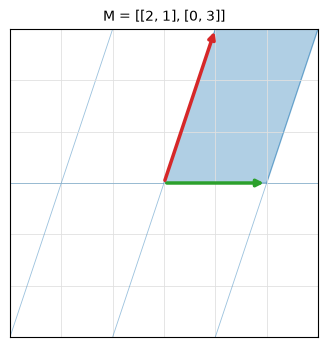

In [32]:
i_hat, j_hat = np.array([1, 0]), np.array([0, 1])
print("M î =", M @ i_hat, "= column 1", M[:, 0])
print("M ĵ =", M @ j_hat, "= column 2", M[:, 1])
show_transform(M, title="M = [[2, 1], [0, 3]]")
plt.show()

### Step 2.3 — Write a matrix from a description
"Rotate 90° counter-clockwise": î → (0, 1), ĵ → (−1, 0). Those images *are* the columns.

In [33]:
R90 = np.column_stack([[0, 1], [-1, 0]])     # column_stack: each list becomes a COLUMN
print(R90)
print("R90 î =", R90 @ [1, 0], "   R90 ĵ =", R90 @ [0, 1])

[[ 0 -1]
 [ 1  0]]
R90 î = [0 1]    R90 ĵ = [-1  0]


### Step 2.4 — Gallery
▶ **Predict** each picture from the columns before running.

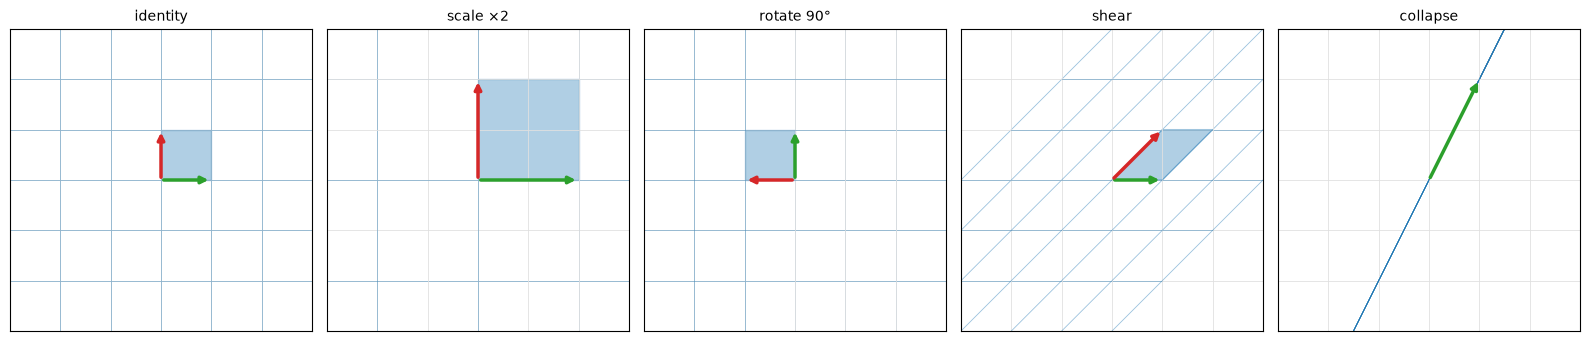

In [34]:
gallery = {"identity":   [[1, 0], [0, 1]],
           "scale ×2":   [[2, 0], [0, 2]],
           "rotate 90°": [[0, -1], [1, 0]],
           "shear":      [[1, 1], [0, 1]],
           "collapse":   [[1, 2], [2, 4]]}
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))   # 1 row × 5 panels side by side (axes = list of 5); figsize in inches
for ax, (name, G) in zip(axes, gallery.items()):
    show_transform(G, ax=ax, title=name)
plt.tight_layout(); plt.show()

### Step 2.5 — Order matters: $AB \neq BA$
`She @ Rot` = rotate first, then shear (inside out).

She @ Rot:
 [[ 1 -1]
 [ 1  0]] 
Rot @ She:
 [[ 0 -1]
 [ 1  1]]
inside out — She @ (Rot @ v) == (She @ Rot) @ v: True


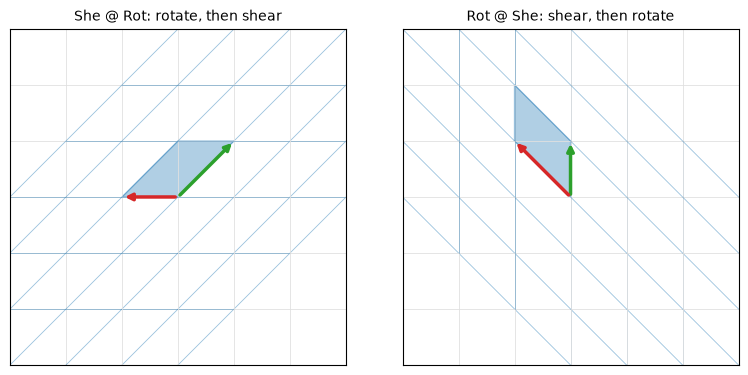

In [35]:
Rot = np.array([[0, -1], [1, 0]])
She = np.array([[1, 1], [0, 1]])
v = np.array([1.0, 2.0])

print("She @ Rot:\n", She @ Rot, "\nRot @ She:\n", Rot @ She)
print("inside out — She @ (Rot @ v) == (She @ Rot) @ v:", np.allclose(She @ (Rot @ v), (She @ Rot) @ v))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
show_transform(She @ Rot, ax=axes[0], title="She @ Rot: rotate, then shear")
show_transform(Rot @ She, ax=axes[1], title="Rot @ She: shear, then rotate")
plt.tight_layout(); plt.show()

### Step 2.6 — Shape rules
NumPy's error message is written in index notation: `(n?,k),(k,m?)->(n?,m?)` — `k` must match and gets summed (Lesson 4 in disguise).

In [36]:
A = rng.normal(size=(5, 3))
B = rng.normal(size=(3, 7))
print("(5×3)(3×7) →", (A @ B).shape)
try:
    B @ A
except ValueError as err:
    print("B @ A →", err)

(5×3)(3×7) → (5, 7)
B @ A → matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 7)


### Code it yourself — `matrix_from_images`, `column_view`

In [37]:
def matrix_from_images(i_img, j_img):
    # TODO: the 2×2 matrix that sends î → i_img and ĵ → j_img
    return None

def column_view(M, v):
    # TODO: M v as a weighted sum of M's columns — no @, no np.dot
    return None

Mt, vt = rng.normal(size=(3, 4)), rng.normal(size=4)
test(matrix_from_images, [(((0, 1), (-1, 0)), np.array([[0, -1], [1, 0]])),
                          (((2, 0), (1, 3)), np.array([[2, 1], [0, 3]]))])
test(column_view, [((np.array([[2, 1], [0, 3]]), np.array([4, 5])), np.array([[2, 1], [0, 3]]) @ np.array([4, 5])),
                   ((Mt, vt), Mt @ vt)])

⏳ matrix_from_images: not implemented yet
⏳ column_view: not implemented yet


<details><summary><b>Reference solution</b></summary>

```python
def matrix_from_images(i_img, j_img):
    return np.column_stack([i_img, j_img])

def column_view(M, v):
    M = np.asarray(M)
    return sum(v[j] * M[:, j] for j in range(M.shape[1]))
```

</details>

### Exercises
**P.Q2** (placement) $A$ is 3×4, $B$ is 4×2. Shape of $AB$? (tuple)

**N2.1** (new) $M = \begin{pmatrix}2&1\\0&3\end{pmatrix}$: where do î and ĵ land? Read it off.

**N2.2** (new) The matrix that mirrors the plane in the x-axis.

**N2.3** (new) The matrix that rotates 90° **clockwise**.

**N2.4** (new) Does a uniform scale $2I$ commute with the 90° rotation? `True` / `False`

In [38]:
P_Q2 = None         # tuple
N2_1_i = None       # [x, y]
N2_1_j = None       # [x, y]
N2_2 = None         # 2×2 nested list
N2_3 = None         # 2×2 nested list
N2_4 = None         # True / False

check("P.Q2", P_Q2, (np.zeros((3, 4)) @ np.zeros((4, 2))).shape)
M = np.array([[2, 1], [0, 3]])
check("N2.1 î", N2_1_i, M @ [1, 0])
check("N2.1 ĵ", N2_1_j, M @ [0, 1])
check("N2.2", N2_2, np.column_stack([[1, 0], [0, -1]]))
check("N2.3", N2_3, np.column_stack([[0, -1], [1, 0]]))
S2, R = 2 * np.eye(2), np.array([[0, -1], [1, 0]])   # eye(2): 2×2 identity matrix
check("N2.4", N2_4, bool(np.allclose(S2 @ R, R @ S2)))

⏳ P.Q2: not answered yet
⏳ N2.1 î: not answered yet
⏳ N2.1 ĵ: not answered yet
⏳ N2.2: not answered yet
⏳ N2.3: not answered yet
⏳ N2.4: not answered yet


---
## Lesson 2b — The determinant
*Vault: `05 Determinant` · MML §4.1 · 3Blue1Brown Ch. 6–7*

$$\det\begin{pmatrix}a&b\\c&d\end{pmatrix} = ad-bc \qquad \det M = \frac{\text{area after}}{\text{area before}} \qquad \det(AB) = \det A\,\det B$$

- **Determinant = area scale factor** (volume in 3D) — a ratio, not an area.
- **Sign = handedness, magnitude = stretch.**
- **det = 0: you can't unscramble an egg** — not one-to-one, no inverse.

### Step 2b.1 — Formula vs NumPy, and a floating-point warning

In [39]:
M = np.array([[3.0, 1.0],
              [1.0, 2.0]])
print("ad − bc =", M[0, 0] * M[1, 1] - M[0, 1] * M[1, 0], "   np.linalg.det =", np.linalg.det(M))

S3 = rng.normal(size=(3, 2)) @ rng.normal(size=(2, 3))   # 3×3 built from only 2 directions → det is 0 in theory
d = np.linalg.det(S3)
print("rank-2 3×3 matrix: det =", d, "→ never test det == 0; use np.isclose:", np.isclose(d, 0))

ad − bc = 5.0    np.linalg.det = 5.000000000000001
rank-2 3×3 matrix: det = -6.332612995837657e-18 → never test det == 0; use np.isclose: True


### Step 2b.2 — A factor, not an area: every shape scales the same
A circle of area 7, area measured with the shoelace formula (no determinant involved).

In [40]:
r = np.sqrt(7 / np.pi)
t = np.linspace(0, 2 * np.pi, 4000, endpoint=False)   # 4000 evenly spaced angles; endpoint=False skips 2π (same point as 0)
circle = np.vstack([r * np.cos(t), r * np.sin(t)])           # 2×N points

for Mx in ([[3, 0], [0, 3]], [[2, 1], [0, 3]], [[1, 2], [0.5, -1]]):
    Mx = np.array(Mx, float)
    before, after = polygon_area(circle), polygon_area(Mx @ circle)
    print(f"det = {np.linalg.det(Mx):+.2f}   area {before:.3f} → {after:.3f}   ratio = {after / before:.3f}")

det = +9.00   area 7.000 → 63.000   ratio = 9.000
det = +6.00   area 7.000 → 42.000   ratio = 6.000
det = -2.00   area 7.000 → 14.000   ratio = 2.000


### Step 2b.3 — $\det(AB) = \det A\cdot\det B$: one scaling, then another

In [41]:
A, B = rng.normal(size=(3, 3)), rng.normal(size=(3, 3))
print(np.linalg.det(A @ B), "==", np.linalg.det(A) * np.linalg.det(B))

-8.660439937654074 == -8.66043993765407


### Step 2b.4 — Sign = handedness
Same two columns, swapped order. Blue fill = orientation kept, orange = flipped.

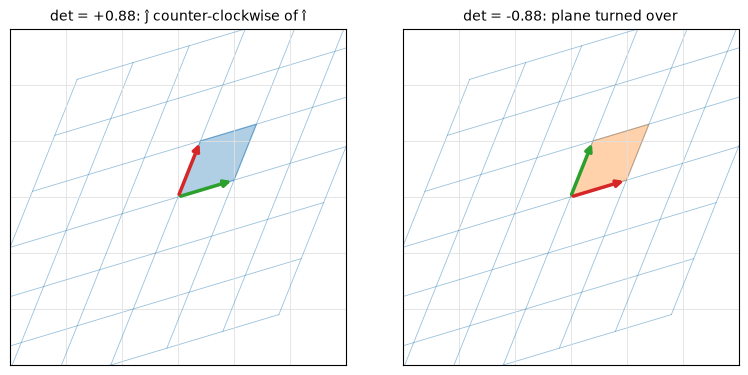

In [42]:
keep = np.array([[1.0, 0.4], [0.3, 1.0]])
flip = keep[:, ::-1]                        # swap the columns
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
show_transform(keep, ax=axes[0], title=f"det = {np.linalg.det(keep):+.2f}: ĵ counter-clockwise of î")
show_transform(flip, ax=axes[1], title=f"det = {np.linalg.det(flip):+.2f}: plane turned over")
plt.tight_layout(); plt.show()

Sliders: move `d` from +1 through 0 to −1 — the square flattens (det = 0), then flips (orange).

In [43]:
def det_demo(a=1.0, b=0.5, c=0.0, d=1.0):
    show_transform([[a, b], [c, d]], title=f"[[{a:.1f}, {b:.1f}], [{c:.1f}, {d:.1f}]]   det = {a * d - b * c:+.2f}")
    plt.show()

interactive(det_demo, a=(-2, 2, 0.1, 1.0), b=(-2, 2, 0.1, 0.5), c=(-2, 2, 0.1, 0.0), d=(-2, 2, 0.1, 1.0))

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='a', max=2.0, min=-2.0), Flo…

### Step 2b.5 — det = 0: information is destroyed (the S2.5 matrix)

In [44]:
S = np.array([[3.0, 6.0],
              [1.0, 2.0]])
print("det =", np.linalg.det(S), "  rank =", np.linalg.matrix_rank(S), "of 2")   # matrix_rank: number of independent columns
print("col 2 = 2 · col 1:", np.allclose(S[:, 1], 2 * S[:, 0]))

null = np.array([2.0, -1.0])                 # S @ null = 0 → this direction is crushed
v1 = np.array([1.0, 1.0])
v2 = v1 + 5 * null
print("S @ v1 =", S @ v1, "   S @ v2 =", S @ v2, " → two inputs, one output")

try:
    Sinv = np.linalg.inv(S)
    print("inv 'worked' only through rounding error — look at the magnitudes:\n", Sinv)
except np.linalg.LinAlgError as err:
    print("np.linalg.inv →", err, "— you can't unscramble an egg")

det = 0.0   rank = 1 of 2
col 2 = 2 · col 1: True
S @ v1 = [9. 3.]    S @ v2 = [9. 3.]  → two inputs, one output
np.linalg.inv → Singular matrix — you can't unscramble an egg


### Step 2b.6 — Physics: proper rotations have det = +1

In [45]:
R = rot2(30)
F = np.array([[1, 0], [0, -1]])             # mirror in the x-axis
print("rotation   det =", round(np.linalg.det(R), 10))
print("reflection det =", np.linalg.det(F))
print("both keep area (|det| = 1); only det = +1 keeps handedness → 'proper' rotation")

rotation   det = 1.0
reflection det = -1.0
both keep area (|det| = 1); only det = +1 keeps handedness → 'proper' rotation


### Code it yourself — `my_det2`, `area_factor`

In [46]:
def my_det2(M):
    # TODO: ad − bc
    return None

def area_factor(M):
    # TODO: area of the transformed unit square — use polygon_area, NOT det
    return None

cases = [np.array([[3.0, 0.0], [0.0, 3.0]]), np.array([[1.0, 2.0], [0.5, -1.0]]), rng.normal(size=(2, 2))]
test(my_det2, [((Mc,), np.linalg.det(Mc)) for Mc in cases])
test(area_factor, [((Mc,), abs(np.linalg.det(Mc))) for Mc in cases])

⏳ my_det2: not implemented yet
⏳ area_factor: not implemented yet


<details><summary><b>Reference solution</b></summary>

```python
def my_det2(M):
    return M[0][0] * M[1][1] - M[0][1] * M[1][0]

def area_factor(M):
    square = np.array([[0, 1, 1, 0], [0, 0, 1, 1]], dtype=float)
    return polygon_area(np.asarray(M, float) @ square)
```

</details>

### Exercises (Set 2 items, reconstructed from the grading notes)
**S2.3** $M = 3I$ (2×2): $\det M$, and the area of a circle of area 7 after $M$.

**S2.5** $M=\begin{pmatrix}3&6\\1&2\end{pmatrix}$: $\det M$, and where does the factor 2 live — `"rows"` or `"cols"`?

**S2.8** $\det M = -2$: area factor? Orientation flipped?

In [47]:
S2_3_det = None
S2_3_area = None
S2_5_det = None
S2_5_where = None       # "rows" or "cols"
S2_8_factor = None
S2_8_flipped = None     # True / False

M3 = 3 * np.eye(2)
check("S2.3 det", S2_3_det, np.linalg.det(M3))
check("S2.3 area", S2_3_area, 7 * abs(np.linalg.det(M3)))
S = np.array([[3.0, 6.0], [1.0, 2.0]])
check("S2.5 det", S2_5_det, np.linalg.det(S))
check("S2.5 where", S2_5_where, "cols" if np.allclose(S[:, 1], 2 * S[:, 0]) else "rows")
check("S2.8 factor", S2_8_factor, abs(-2))
check("S2.8 flipped", S2_8_flipped, -2 < 0)

⏳ S2.3 det: not answered yet
⏳ S2.3 area: not answered yet
⏳ S2.5 det: not answered yet
⏳ S2.5 where: not answered yet
⏳ S2.8 factor: not answered yet
⏳ S2.8 flipped: not answered yet


---
## Lesson 3 — Transpose and the shape game
*Vault: `06 Transpose and Shape Rules` · MML §2.2 · [PyTorch `nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) · [NumPy broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html)*

$$(A^\top)_{ij} = A_{ji} \qquad (AB)^\top = B^\top A^\top \qquad a\cdot b = a^\top b$$

- **Socks and shoes:** undoing a composition reverses the order — also $(AB)^{-1} = B^{-1}A^{-1}$.
- **$A^\top A$: inner $m$'s cancel, outer $n$'s survive** → always $n\times n$.
- **Batch-first data** → $XW^\top$, not $WX$. The transpose only lines up the axis to be summed.

### Step 3.1 — Transpose = swap the indices

In [48]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print(A.T, "\nshape", A.shape, "→", A.T.shape)
print("(Aᵀ)_ij == A_ji everywhere:", all(A.T[i, j] == A[j, i] for i in range(3) for j in range(2)))

[[1 4]
 [2 5]
 [3 6]] 
shape (2, 3) → (3, 2)
(Aᵀ)_ij == A_ji everywhere: True


### Step 3.2 — Socks and shoes, forced by shapes
▶ **Predict:** which of `B.T @ A.T` and `A.T @ B.T` is even defined? (S3.2)

In [49]:
A = rng.normal(size=(4, 2))
B = rng.normal(size=(2, 6))
print("(AB)ᵀ:", (A @ B).T.shape, "  BᵀAᵀ:", (B.T @ A.T).shape, "  equal:", np.allclose((A @ B).T, B.T @ A.T))
try:
    A.T @ B.T
except ValueError:
    print("AᵀBᵀ = (2×4)(6×2) → undefined. Only the reversed order fits.")

P, Q = rng.normal(size=(3, 3)), rng.normal(size=(3, 3))
inv = np.linalg.inv
print("(PQ)⁻¹ = Q⁻¹P⁻¹:", np.allclose(inv(P @ Q), inv(Q) @ inv(P)),
      "   (PQ)⁻¹ = P⁻¹Q⁻¹:", np.allclose(inv(P @ Q), inv(P) @ inv(Q)))

(AB)ᵀ: (6, 4)   BᵀAᵀ: (6, 4)   equal: True
AᵀBᵀ = (2×4)(6×2) → undefined. Only the reversed order fits.
(PQ)⁻¹ = Q⁻¹P⁻¹: True    (PQ)⁻¹ = P⁻¹Q⁻¹: False


### Step 3.3 — $A^\top A$ is always square (and symmetric): the Gram matrix

In [50]:
for shape in [(3, 1), (1, 3), (5, 2), (2, 7)]:
    A = rng.normal(size=shape)
    G = A.T @ A
    print(f"A {str(shape):7s} → AᵀA {str(G.shape):7s} symmetric: {np.allclose(G, G.T)}")

A (3, 1)  → AᵀA (1, 1)  symmetric: True
A (1, 3)  → AᵀA (3, 3)  symmetric: True
A (5, 2)  → AᵀA (2, 2)  symmetric: True
A (2, 7)  → AᵀA (7, 7)  symmetric: True


### Step 3.4 — Vectors in NumPy: 1-D arrays are orientation-blind

In [51]:
a = np.array([1, 2, 3])
print("1-D:", a.shape, "   a.T:", a.T.shape, "← no-op")
col = a[:, None]                         # explicit 3×1 column (same as a.reshape(-1, 1))
print("column:", col.shape, "   row:", col.T.shape)
print("aᵀa →", (col.T @ col).shape, "=", (col.T @ col).item(), "= ‖a‖²")   # .item(): 1×1 array → plain number
print("aaᵀ →", (col @ col.T).shape, "(outer product)\n", col @ col.T)
print("np.outer(a, a) is the same:", np.allclose(np.outer(a, a), col @ col.T))   # outer(a, b)[i, j] = a[i] * b[j]

1-D: (3,)    a.T: (3,) ← no-op
column: (3, 1)    row: (1, 3)
aᵀa → (1, 1) = 14 = ‖a‖²
aaᵀ → (3, 3) (outer product)
 [[1 2 3]
 [2 4 6]
 [3 6 9]]
np.outer(a, a) is the same: True


### Step 3.5 — The shape game: a linear layer
$X$ = (batch × in_features), $W$ = (out_features × in_features) — the layout of `torch.nn.Linear`, which computes $y = xW^\top + b$.

In [52]:
X = rng.normal(size=(32, 784))      # 32 flattened 28×28 images
W = rng.normal(size=(128, 784))     # 128 outputs, each reading all 784 inputs
b = rng.normal(size=128)

Y = X @ W.T + b                     # (32×784)(784×128) → 32×128; b broadcasts over the batch
print(Y.shape)
print("row 0 of Y = W applied to sample 0:", np.allclose(Y[0], W @ X[0] + b))

(32, 128)
row 0 of Y = W applied to sample 0: True


### Code it yourself — `my_transpose`, `linear_layer`

In [53]:
def my_transpose(A):
    # TODO: loops only — out[i, j] = A[j, i]
    return None

def linear_layer(X, W, b):
    # TODO: X (batch, in), W (out, in), b (out,) → (batch, out)
    return None

At = rng.normal(size=(2, 5))
Xt, Wt, bt = rng.normal(size=(4, 3)), rng.normal(size=(2, 3)), rng.normal(size=2)
test(my_transpose, [((At,), At.T), ((np.array([[1, 2, 3], [4, 5, 6]]),), np.array([[1, 4], [2, 5], [3, 6]]))])
test(linear_layer, [((Xt, Wt, bt), np.array([Wt @ x + bt for x in Xt]))])

⏳ my_transpose: not implemented yet
⏳ linear_layer: not implemented yet


<details><summary><b>Reference solution</b></summary>

```python
def my_transpose(A):
    m, n = A.shape
    out = np.zeros((n, m), dtype=A.dtype)
    for i in range(n):
        for j in range(m):
            out[i, j] = A[j, i]
    return out

def linear_layer(X, W, b):
    return X @ W.T + b
```

</details>

### Exercises — Set 3
**S3.1** $A = \begin{pmatrix}1&2\\3&4\\5&6\end{pmatrix}$: write $A^\top$ and both shapes.

**S3.2** $A$ is 4×2, $B$ is 2×6: shapes of (a) $AB$ (b) $(AB)^\top$ (c) $B^\top A^\top$. Do (b) and (c) match?

**S3.3** $a=(1,2,3)$ as a column: shapes of $a^\top a$ and $aa^\top$; value of $a^\top a$.

**S3.4** $\det A = 3$, $\det B = -2$: $\det(AB)$, area factor, orientation flipped?

**S3.5** $X$ (64×1024), $W$ (256×1024): shape of $XW^\top$ and the size of the summed index.

**S3.6** True or false: $A^\top A$ is square for every $A$.

**S3.7** $\det M = 0$: can $M$ be inverted?

In [54]:
S3_1_AT = None          # nested list
S3_1_shape_A = None     # tuple
S3_1_shape_AT = None    # tuple
S3_2_a = None           # tuple
S3_2_b = None           # tuple
S3_2_c = None           # tuple
S3_2_match = None       # True / False
S3_3_shape_ata = None   # tuple
S3_3_shape_aat = None   # tuple
S3_3_value = None
S3_4_det = None
S3_4_factor = None
S3_4_flipped = None     # True / False
S3_5_shape = None       # tuple
S3_5_summed = None      # integer
S3_6 = None             # True / False
S3_7 = None             # True / False

A = np.array([[1, 2], [3, 4], [5, 6]])
check("S3.1 Aᵀ", S3_1_AT, A.T)
check("S3.1 shape A", S3_1_shape_A, A.shape)
check("S3.1 shape Aᵀ", S3_1_shape_AT, A.T.shape)
A, B = np.zeros((4, 2)), np.zeros((2, 6))
check("S3.2a", S3_2_a, (A @ B).shape)
check("S3.2b", S3_2_b, (A @ B).T.shape)
check("S3.2c", S3_2_c, (B.T @ A.T).shape)
check("S3.2 match", S3_2_match, (A @ B).T.shape == (B.T @ A.T).shape)
col = np.array([[1], [2], [3]])
check("S3.3 aᵀa shape", S3_3_shape_ata, (col.T @ col).shape)
check("S3.3 aaᵀ shape", S3_3_shape_aat, (col @ col.T).shape)
check("S3.3 value", S3_3_value, (col.T @ col).item())
A, B = np.array([[2.0, 1.0], [1.0, 2.0]]), np.array([[0.0, 1.0], [2.0, 1.0]])     # det 3 and det −2
check("S3.4 det", S3_4_det, np.linalg.det(A @ B))
check("S3.4 factor", S3_4_factor, abs(np.linalg.det(A @ B)))
check("S3.4 flipped", S3_4_flipped, bool(np.linalg.det(A @ B) < 0))
X, W = np.zeros((64, 1024)), np.zeros((256, 1024))
check("S3.5 shape", S3_5_shape, (X @ W.T).shape)
check("S3.5 summed", S3_5_summed, X.shape[1])
check("S3.6", S3_6, True)
check("S3.7", S3_7, False)

⏳ S3.1 Aᵀ: not answered yet
⏳ S3.1 shape A: not answered yet
⏳ S3.1 shape Aᵀ: not answered yet
⏳ S3.2a: not answered yet
⏳ S3.2b: not answered yet
⏳ S3.2c: not answered yet
⏳ S3.2 match: not answered yet
⏳ S3.3 aᵀa shape: not answered yet
⏳ S3.3 aaᵀ shape: not answered yet
⏳ S3.3 value: not answered yet
⏳ S3.4 det: not answered yet
⏳ S3.4 factor: not answered yet
⏳ S3.4 flipped: not answered yet
⏳ S3.5 shape: not answered yet
⏳ S3.5 summed: not answered yet
⏳ S3.6: not answered yet
⏳ S3.7: not answered yet


---
## Lesson 4 — Einstein notation → `np.einsum`
*Vault: `07 Einstein Notation` · MML §2.2 · Griffiths §1.1–1.2 · [`np.einsum` docs](https://numpy.org/doc/stable/reference/generated/numpy.einsum.html)*

$$(AB)_{ij} = \sum_k A_{ik}B_{kj} \;\longrightarrow\; (AB)_{ij} = A_{ik}B_{kj}$$

- **Rank = number of indices** (`ndim`). Components = dimension$^{\text{rank}}$ (`size`).
- **Repeat it, and it's gone. Write it once, and it's an output dimension.**
- **Once = free, twice = summed, three times = a mistake.**
- **Position doesn't matter — only letters do.**
- In einsum **the `->` decides**: a letter written after the arrow is kept (e.g. a batch index), even if repeated.

### Step 4.1 — Rank = `ndim`, components = `size`

In [55]:
for name, T in [("scalar s",                        np.array(5.0)),
                ("vector v_i",                      np.zeros(3)),
                ("matrix M_ij",                     np.zeros((3, 3))),
                ("rank-3 T_ijk, indices 1–4",       np.zeros((4, 4, 4))),
                ("images (batch, channels, H, W)",  np.zeros((8, 3, 28, 28)))]:
    # ndim: number of indices; size: total number of entries
    print(f"{name:32s} rank = {T.ndim}   shape = {str(T.shape):15s} components = {T.size}")

scalar s                         rank = 0   shape = ()              components = 1
vector v_i                       rank = 1   shape = (3,)            components = 3
matrix M_ij                      rank = 2   shape = (3, 3)          components = 9
rank-3 T_ijk, indices 1–4        rank = 3   shape = (4, 4, 4)       components = 64
images (batch, channels, H, W)   rank = 4   shape = (8, 3, 28, 28)  components = 18816


### Step 4.2 — Rosetta stone: every operation you know is one einsum

In [56]:
a, b = rng.normal(size=3), rng.normal(size=3)
A, B = rng.normal(size=(3, 3)), rng.normal(size=(3, 3))
M, v = rng.normal(size=(2, 3)), rng.normal(size=3)
X, Y = rng.normal(size=(5, 2, 3)), rng.normal(size=(5, 3, 4))

rosetta = [
    # einsum("input letters -> output letters", operands...): repeated letters are summed (Step 4.2)
    ("dot product     a_i b_i",     np.einsum("i,i->", a, b),        a @ b),
    ("matrix×vector   M_ij v_j",    np.einsum("ij,j->i", M, v),      M @ v),
    ("matrix×matrix   A_ik B_kj",   np.einsum("ik,kj->ij", A, B),    A @ B),
    ("transpose       A_ji",        np.einsum("ij->ji", A),          A.T),
    ("trace           A_ii",        np.einsum("ii->", A),            np.trace(A)),   # trace: sum of the diagonal (Lesson 5)
    ("outer product   a_i b_j",     np.einsum("i,j->ij", a, b),      np.outer(a, b)),
    ("batched matmul  X_bnm Y_bmp", np.einsum("bnm,bmp->bnp", X, Y), X @ Y),
]
for name, via_einsum, via_numpy in rosetta:
    print(f"{name:30s} result shape {str(np.shape(via_einsum)):10s} matches NumPy: {np.allclose(via_einsum, via_numpy)}")

dot product     a_i b_i        result shape ()         matches NumPy: True
matrix×vector   M_ij v_j       result shape (2,)       matches NumPy: True
matrix×matrix   A_ik B_kj      result shape (3, 3)     matches NumPy: True
transpose       A_ji           result shape (3, 3)     matches NumPy: True
trace           A_ii           result shape ()         matches NumPy: True
outer product   a_i b_j        result shape (3, 3)     matches NumPy: True
batched matmul  X_bnm Y_bmp    result shape (5, 2, 4)  matches NumPy: True


### Step 4.3 — The grammar as code
`analyze` applies the counting rules to a spec. Pure Einstein notation has no "carried" index — keeping a repeated letter (batch) is einsum's extension, which is why the `->` matters.
For pure Einstein expressions: **rank = total indices − 2 × repeated pairs.**

In [57]:
def analyze(spec):
    """Once = free, twice = summed, 3+ = not valid Einstein notation."""
    lhs, arrow, rhs = spec.replace(" ", "").partition("->")   # partition: split at the first "->" → (before, "->", after); arrow is "" if missing
    counts = Counter(ch for ch in lhs if ch.isalpha())   # Counter: letter → how often it appears; isalpha skips the commas
    free = rhs if arrow else "".join(sorted(ch for ch, n in counts.items() if n == 1))
    summed  = [ch for ch, n in sorted(counts.items()) if n >= 2 and ch not in free]
    carried = [ch for ch, n in sorted(counts.items()) if n >= 2 and ch in free]
    illegal = [ch for ch, n in sorted(counts.items()) if n >= 3]
    msg = (f"{spec:15s} free: {','.join(free) or '—':6s} summed: {','.join(summed) or '—':5s} "
           f"carried: {','.join(carried) or '—':3s} → rank {len(free)}")
    if illegal:
        msg += f"   ⚠ {','.join(illegal)} appears 3+ times"
    print(msg)

for spec in ["ij,jk->ik", "ij,ij->", "ij,j->i", "i,j->ij", "ii->", "ijk,k->ij", "bnm,bmp->bnp", "ii,ij->j"]:
    analyze(spec)

ij,jk->ik       free: i,k    summed: j     carried: —   → rank 2
ij,ij->         free: —      summed: i,j   carried: —   → rank 0
ij,j->i         free: i      summed: j     carried: —   → rank 1
i,j->ij         free: i,j    summed: —     carried: —   → rank 2
ii->            free: —      summed: i     carried: —   → rank 0
ijk,k->ij       free: i,j    summed: k     carried: —   → rank 2
bnm,bmp->bnp    free: b,n,p  summed: m     carried: b   → rank 3
ii,ij->j        free: j      summed: i     carried: —   → rank 1   ⚠ i appears 3+ times


### Step 4.4 — Same rule, any rank: $T_{ijk}v_k$ is a matrix

In [58]:
T = rng.normal(size=(2, 3, 4))
v4 = rng.normal(size=4)
Tv = np.einsum("ijk,k->ij", T, v4)
print(Tv.shape, "   same as T @ v:", np.allclose(Tv, T @ v4))

(2, 3)    same as T @ v: True


### Step 4.5 — Position doesn't matter, only letters do (your drill questions)
$A_{ij}B_{ij}$ is a scalar because *both* letters repeat; the slots only decide *which* entries pair up. Same for mixing matrices and vectors: $v_iA_{ij}$ and $A_{ij}v_j$ are both vectors — but indexed by different letters.

In [59]:
A, B = rng.normal(size=(3, 3)), rng.normal(size=(3, 3))
v = rng.normal(size=3)
print("A_ij B_ij = B_ij A_ij        :", np.isclose(np.einsum("ij,ij->", A, B), np.einsum("ij,ij->", B, A)))
print("A_ij B_ij = tr(AᵀB)          :", np.isclose(np.einsum("ij,ij->", A, B), np.trace(A.T @ B)))
print("A_ij B_ji = tr(AB)           :", np.isclose(np.einsum("ij,ji->", A, B), np.trace(A @ B)))
print("v_i A_ij  = (vᵀA)_j = (Aᵀv)_j:", np.allclose(np.einsum("i,ij->j", v, A), A.T @ v))
print("A_ij v_j  = (Av)_i           :", np.allclose(np.einsum("ij,j->i", A, v), A @ v))

A_ij B_ij = B_ij A_ij        : True
A_ij B_ij = tr(AᵀB)          : True
A_ij B_ji = tr(AB)           : True
v_i A_ij  = (vᵀA)_j = (Aᵀv)_j: True
A_ij v_j  = (Av)_i           : True


### Step 4.6 — Three times = a mistake, and NumPy will not stop you
NumPy evaluates $A_{ii}B_{ij}$ as $\sum_i A_{ii}B_{ij}$ — it just picks one reading of an ambiguous expression. Checking legality is your job.

In [60]:
A, B = rng.normal(size=(3, 3)), rng.normal(size=(3, 3))
print("einsum('ii,ij->j') runs anyway:", np.einsum("ii,ij->j", A, B))
print("fixed by renaming — A_kk B_ij = tr(A)·B:", np.allclose(np.einsum("kk,ij->ij", A, B), np.trace(A) * B))

einsum('ii,ij->j') runs anyway: [0.5184 1.0039 0.0365]
fixed by renaming — A_kk B_ij = tr(A)·B: True


### Code it yourself — write the einsum specs
Replace each `None` with a spec string (always write the `->`).

In [61]:
specs = {
    "dot":       None,   # a_i b_i       → scalar
    "matvec":    None,   # M_ij v_j      → vector
    "matmul":    None,   # A_ik B_kj     → matrix
    "outer":     None,   # a_i b_j       → matrix
    "trace":     None,   # A_ii          → scalar
    "frob":      None,   # A_ij B_ij     → scalar
    "batched":   None,   # X_bnm Y_bmp   → (b, n, p)
    "contract3": None,   # T_ijk v_k     → matrix
}

a, b = rng.normal(size=3), rng.normal(size=3)
A, B, M = rng.normal(size=(3, 3)), rng.normal(size=(3, 3)), rng.normal(size=(2, 3))
X, Y, T = rng.normal(size=(4, 2, 3)), rng.normal(size=(4, 3, 5)), rng.normal(size=(2, 3, 3))
targets = {"dot": ((a, b), a @ b),          "matvec": ((M, a), M @ a),
           "matmul": ((A, B), A @ B),       "outer": ((a, b), np.outer(a, b)),
           "trace": ((A,), np.trace(A)),    "frob": ((A, B), np.sum(A * B)),
           "batched": ((X, Y), X @ Y),      "contract3": ((T, a), T @ a)}
for name, spec in specs.items():
    operands, expected = targets[name]
    check(f"einsum.{name}", run_spec(spec, *operands), expected)

⏳ einsum.dot: not answered yet
⏳ einsum.matvec: not answered yet
⏳ einsum.matmul: not answered yet
⏳ einsum.outer: not answered yet
⏳ einsum.trace: not answered yet
⏳ einsum.frob: not answered yet
⏳ einsum.batched: not answered yet
⏳ einsum.contract3: not answered yet


<details><summary><b>Reference solution</b></summary>

```python
specs = {
    "dot":       "i,i->",
    "matvec":    "ij,j->i",
    "matmul":    "ik,kj->ij",
    "outer":     "i,j->ij",
    "trace":     "ii->",
    "frob":      "ij,ij->",
    "batched":   "bnm,bmp->bnp",
    "contract3": "ijk,k->ij",
}
```

</details>

### Exercises — Set 4
**S4.1** Rank of the result for (a) $A_{ij}B_{jk}$ (b) $A_{ij}B_{ij}$ (c) $A_{ij}v_j$ (d) $a_ib_j$ — list `[a, b, c, d]`.

**S4.2** einsum spec for $\operatorname{tr}(M)$.

**S4.3** $T_{ijk}$, each index running 1–4: number of components.

**S4.4** einsum spec for $c_i = \sum_j\sum_k A_{ij}B_{jk}v_k$, and the rank of $c$.

**S4.5** What is wrong with $A_{ii}B_{ij}$? (words — see solution below)

**S4.6** einsum spec for batched matmul (b,n,m)·(b,m,p) → (b,n,p). Which letter is summed?

**S4.7** einsum specs for $a\cdot b$ and $\lVert a\rVert^2$.

**P.Q6** (placement) Components of a rank-2 tensor in 3D.

In [62]:
S4_1 = None          # list of 4 ranks
S4_2 = None          # spec string
S4_3 = None          # integer
S4_4_spec = None     # spec string (three operands: A, B, v)
S4_4_rank = None     # integer
S4_6_spec = None     # spec string
S4_6_summed = None   # one letter
S4_7_dot = None      # spec string (operands a, b)
S4_7_norm2 = None    # spec string (operands a, a)
P_Q6 = None          # integer

A, B, Mt = rng.normal(size=(3, 3)), rng.normal(size=(3, 3)), rng.normal(size=(3, 3))
v, a, b = rng.normal(size=3), rng.normal(size=3), rng.normal(size=3)
X, Y = rng.normal(size=(4, 2, 3)), rng.normal(size=(4, 3, 5))

check("S4.1", S4_1, [np.einsum(s, *ops).ndim for s, ops in
                     [("ij,jk->ik", (A, B)), ("ij,ij->", (A, B)), ("ij,j->i", (A, v)), ("i,j->ij", (a, b))]])
check("S4.2", run_spec(S4_2, Mt), np.trace(Mt))
check("S4.3", S4_3, np.zeros((4, 4, 4)).size)
check("S4.4 spec", run_spec(S4_4_spec, A, B, v), A @ B @ v)
check("S4.4 rank", S4_4_rank, (A @ B @ v).ndim)
check("S4.6 spec", run_spec(S4_6_spec, X, Y), X @ Y)
check("S4.6 summed", S4_6_summed, "m")
check("S4.7 a·b", run_spec(S4_7_dot, a, b), a @ b)
check("S4.7 ‖a‖²", run_spec(S4_7_norm2, a, a), a @ a)
check("P.Q6", P_Q6, np.zeros((3, 3)).size)

⏳ S4.1: not answered yet
⏳ S4.2: not answered yet
⏳ S4.3: not answered yet
⏳ S4.4 spec: not answered yet
⏳ S4.4 rank: not answered yet
⏳ S4.6 spec: not answered yet
⏳ S4.6 summed: not answered yet
⏳ S4.7 a·b: not answered yet
⏳ S4.7 ‖a‖²: not answered yet
⏳ P.Q6: not answered yet


<details><summary><b>S4.5 and S4.4 in words</b></summary>

**S4.5** $i$ appears three times. Once = free, twice = summed, three times = the notation can't say whether it means a trace or a contraction. Rename: $A_{kk}B_{ij}$.

**S4.4** $c_i = A_{ij}B_{jk}v_k$ — delete the sigmas, change nothing else. Rank 1: $B$ acts on $v$ first, then $A$.

</details>

---
## Lesson 4b — The trace
*Vault: `08 Trace` · MML §4.1, §4.2, Ch. 10 · Griffiths §1.1*

$$\operatorname{tr}(A) = A_{ii} \qquad \operatorname{tr}(AB) = \operatorname{tr}(BA) \qquad \operatorname{tr}(A^\top B) = A_{ij}B_{ij} \qquad \operatorname{tr}A = \sum_i\lambda_i,\ \ \det A = \prod_i\lambda_i$$

- **Trace = what survives your choice of coordinates.**
- **Cyclic: rotate the letters, don't reorder them.**
- **Trace is the infinitesimal determinant:** $\det(I+\varepsilon A) \approx 1 + \varepsilon\operatorname{tr}A$.

### Step 4b.1 — Four ways to compute it

In [63]:
A = np.array([[2, 7, 1],
              [0, 5, 3],
              [4, 8, -1]])
print(np.trace(A), np.einsum("ii->", A), A.diagonal().sum(), sum(A[i, i] for i in range(3)))

6 6 6 6


### Step 4b.2 — Cyclic: rotate the letters, don't reorder them

In [64]:
tr = np.trace
A, B, C = (rng.normal(size=(3, 3)) for _ in range(3))
print("tr(AB) = tr(BA):", np.isclose(tr(A @ B), tr(B @ A)), "   but AB = BA:", np.allclose(A @ B, B @ A))
print("tr(ABC), tr(BCA), tr(CAB):", tr(A @ B @ C), tr(B @ C @ A), tr(C @ A @ B))
print("tr(ACB) — reordered:      ", tr(A @ C @ B))

A23, B32 = rng.normal(size=(2, 3)), rng.normal(size=(3, 2))
print("\nnon-square: AB is", (A23 @ B32).shape, "BA is", (B32 @ A23).shape,
      "— traces:", tr(A23 @ B32), tr(B32 @ A23))

tr(AB) = tr(BA): True    but AB = BA: False
tr(ABC), tr(BCA), tr(CAB): 7.68812496526418 7.688124965264182 7.68812496526418
tr(ACB) — reordered:       2.4652016371396472

non-square: AB is (2, 2) BA is (3, 3) — traces: 5.0721127185612245 5.0721127185612245


### Step 4b.3 — The diagonals do NOT stay the same (S5.5)

In [65]:
A = np.array([[1, 2], [10, 0]])
B = np.array([[1, 1], [1, 1]])
print("diag(AB) =", np.diag(A @ B), "   diag(BA) =", np.diag(B @ A))   # diag(matrix): its diagonal as a 1-D array
print("tr(AB) =", np.trace(A @ B), "   tr(BA) =", np.trace(B @ A), "← only the total survives")

diag(AB) = [ 3 10]    diag(BA) = [11  2]
tr(AB) = 13    tr(BA) = 13 ← only the total survives


### Step 4b.4 — The index proof, executed
$\operatorname{tr}(AB) = A_{ik}B_{ki}$ and $\operatorname{tr}(BA) = B_{ik}A_{ki}$. Rename the dummies $i\leftrightarrow k$ in the second: $B_{ki}A_{ik} = A_{ik}B_{ki}$. Same sum over all pairs.

In [66]:
A, B = rng.normal(size=(4, 4)), rng.normal(size=(4, 4))
trAB = np.einsum("ik,ki->", A, B)             # A_ik B_ki
trBA = np.einsum("ik,ki->", B, A)             # B_ik A_ki
trBA_renamed = np.einsum("ki,ik->", B, A)     # rename i↔k → B_ki A_ik = A_ik B_ki
all_pairs = sum(A[i, k] * B[k, i] for i in range(4) for k in range(4))
print(trAB, trBA, trBA_renamed, all_pairs)

-7.803437822390903 -7.803437822390903 -7.803437822390903 -7.803437822390903


### Step 4b.5 — The matrix dot product (Frobenius) — a.k.a. the weight-decay penalty

In [67]:
W = rng.normal(size=(5, 3))
print("tr(WᵀW) =", np.trace(W.T @ W))
print("Σ W_ij² =", np.sum(W**2))
print("‖W‖_F²  =", np.linalg.norm(W, "fro")**2)   # "fro" = Frobenius norm √(Σ W_ij²)

tr(WᵀW) = 16.51649094851868
Σ W_ij² = 16.516490948518683
‖W‖_F²  = 16.516490948518687


### Step 4b.6 — Trace = Σλ, det = Πλ
Eigenvalues are a black box until Lesson 5. Non-symmetric matrices can have complex eigenvalues; they come in conjugate pairs, so sum and product stay real.

In [68]:
A = rng.normal(size=(4, 4))
lam = np.linalg.eigvals(A)   # eigenvalues of A (can be complex → .real below)
print("eigenvalues:", lam)
print("Σλ =", lam.sum().real, "   tr  =", np.trace(A))
print("Πλ =", lam.prod().real, "   det =", np.linalg.det(A))

eigenvalues: [-1.2608+0.j      0.8243+1.4951j  0.8243-1.4951j  2.1894+0.j    ]
Σλ = 2.5771150920803594    tr  = 2.577115092080359
Πλ = -8.045576093512818    det = -8.045576093512825


### Step 4b.7 — Basis-invariant: $\operatorname{tr}(P^{-1}AP) = \operatorname{tr}(A)$
Then on data: rotate a point cloud — every covariance entry moves, the total variance doesn't.

entries changed: True    trace kept: True    det kept: True


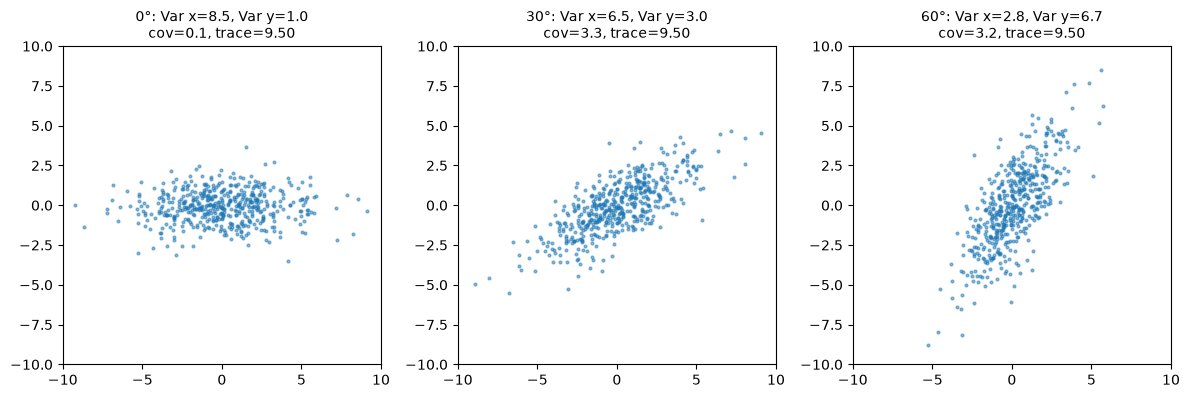

In [69]:
A, P = rng.normal(size=(3, 3)), rng.normal(size=(3, 3))
A_new = np.linalg.inv(P) @ A @ P
print("entries changed:", not np.allclose(A, A_new), "   trace kept:", np.isclose(np.trace(A), np.trace(A_new)),
      "   det kept:", np.isclose(np.linalg.det(A), np.linalg.det(A_new)))

Xc = rng.normal(size=(500, 2)) * [3.0, 1.0]             # wide in x, narrow in y
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, deg in zip(axes, (0, 30, 60)):
    Xr = Xc @ rot2(deg).T                               # rows = points → right-multiply by Rᵀ (shape game)
    S = np.cov(Xr, rowvar=False)   # covariance matrix; rowvar=False: rows are samples, columns are variables
    ax.scatter(*Xr.T, s=4, alpha=0.5)   # *Xr.T unpacks into (x-coords, y-coords); s = marker size, alpha = transparency
    ax.set_aspect("equal"); ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
    ax.set_title(f"{deg}°: Var x={S[0, 0]:.1f}, Var y={S[1, 1]:.1f}\ncov={S[0, 1]:.1f}, trace={np.trace(S):.2f}", fontsize=10)
plt.tight_layout(); plt.show()

### Step 4b.8 — Trace is the infinitesimal determinant
The gap shrinks like ε² — trace is the *rate* at which area starts to change.

In [70]:
A = rng.normal(size=(3, 3))
for eps in (1e-1, 1e-2, 1e-3):
    lhs, rhs = np.linalg.det(np.eye(3) + eps * A), 1 + eps * np.trace(A)
    print(f"ε = {eps:<6g} det(I+εA) = {lhs:.8f}   1+ε·tr(A) = {rhs:.8f}   gap = {abs(lhs - rhs):.1e}")

ε = 0.1    det(I+εA) = 1.24156512   1+ε·tr(A) = 1.22609261   gap = 1.5e-02
ε = 0.01   det(I+εA) = 1.02276379   1+ε·tr(A) = 1.02260926   gap = 1.5e-04
ε = 0.001  det(I+εA) = 1.00226247   1+ε·tr(A) = 1.00226093   gap = 1.5e-06


### Step 4b.9 — Where you'll meet it
**ML:** PCA explained variance = eigenvalue ÷ trace. **Physics:** a 3D rotation's angle from its trace, $\operatorname{tr}R = 1 + 2\cos\theta$; the mean normal stress $\operatorname{tr}\sigma/3$ (pressure, up to sign convention) doesn't depend on the axes.

In [71]:
data = rng.normal(size=(1000, 3)) @ np.array([[3.0, 0.0, 0.0], [1.0, 1.0, 0.0], [0.0, 0.5, 0.2]])
Sigma = np.cov(data, rowvar=False)
lam = np.linalg.eigvalsh(Sigma)[::-1]                  # symmetric → eigvalsh; sort descending
print("total variance tr(Σ) =", round(np.trace(Sigma), 4), "= Σλ =", round(lam.sum(), 4))
print("explained variance ratio per component:", lam / np.trace(Sigma))

R = rotation_3d([1, 2, 2], 40)
print("\ndet R =", round(np.linalg.det(R), 10), "→ proper rotation")
print(f"angle from the trace alone: {np.degrees(np.arccos((np.trace(R) - 1) / 2)):.4f}°  (built with 40°)")

sigma = np.array([[5.0, 1.0, 0.0],
                  [1.0, 3.0, 2.0],
                  [0.0, 2.0, 4.0]])                  # symmetric stress tensor, arbitrary units
sigma_rot = R @ sigma @ R.T                           # same stress, rotated axes (why R·σ·Rᵀ → Lesson 6)
print("\nstress components changed:", not np.allclose(sigma, sigma_rot))
print("tr(σ)/3:", np.trace(sigma) / 3, "→", round(np.trace(sigma_rot) / 3, 10))

total variance tr(Σ) = 11.139 = Σλ = 11.139
explained variance ratio per component: [0.8979 0.0993 0.0028]

det R = 1.0 → proper rotation
angle from the trace alone: 40.0000°  (built with 40°)

stress components changed: True
tr(σ)/3: 4.0 → 4.0


### Code it yourself — `my_trace`, `frobenius`

In [72]:
def my_trace(A):
    # TODO: loop over the diagonal
    return None

def frobenius(A, B):
    # TODO: Σ_ij A_ij B_ij — no @, no np.trace
    return None

At, Bt = rng.normal(size=(4, 4)), rng.normal(size=(4, 4))
test(my_trace, [((np.array([[2, 7, 1], [0, 5, 3], [4, 8, -1]]),), 6), ((At,), np.trace(At))])
test(frobenius, [((At, Bt), np.trace(At.T @ Bt)), ((At, At), np.linalg.norm(At, "fro")**2)])

⏳ my_trace: not implemented yet
⏳ frobenius: not implemented yet


<details><summary><b>Reference solution</b></summary>

```python
def my_trace(A):
    return sum(A[i, i] for i in range(A.shape[0]))

def frobenius(A, B):
    return np.sum(A * B)
```

</details>

### Exercises — Set 5
**S5.1** $\operatorname{tr}\begin{pmatrix}3&9\\-2&4\end{pmatrix}$.

**S5.2** $A = \begin{pmatrix}1&2\\3&4\end{pmatrix}$: $\lVert A\rVert_F^2$ via $\operatorname{tr}(A^\top A)$.

**S5.3** $\operatorname{tr}(I_n)$ — answer as a function, e.g. `lambda n: ...`

**S5.4** A 2×2 matrix has eigenvalues 5 and −2: trace and determinant.

**S5.5** Why is $\operatorname{tr}(AB) = \operatorname{tr}(BA)$ not a contradiction of $AB \neq BA$? (words — see Step 4b.3/4b.4)

**S5.6** $\operatorname{tr}(\Sigma) = 40$, largest eigenvalue 30: fraction of variance explained by PC1.

In [73]:
S5_1 = None
S5_2 = None
S5_3 = None           # lambda n: ...
S5_4_trace = None
S5_4_det = None
S5_6 = None           # fraction, e.g. 0.5

def _apply(f):
    if f is None:
        return None
    try:
        return [f(n) for n in (1, 4, 50)]
    except Exception as err:
        return f"not a function of n ({err})"

check("S5.1", S5_1, np.trace(np.array([[3, 9], [-2, 4]])))
A = np.array([[1, 2], [3, 4]])
check("S5.2", S5_2, np.trace(A.T @ A))
check("S5.3", _apply(S5_3), [np.trace(np.eye(n)) for n in (1, 4, 50)])
P = rng.normal(size=(2, 2))
A54 = np.linalg.inv(P) @ np.diag([5.0, -2.0]) @ P      # some matrix with eigenvalues 5 and −2
check("S5.4 trace", S5_4_trace, np.trace(A54))
check("S5.4 det", S5_4_det, np.linalg.det(A54))
check("S5.6", S5_6, 30 / 40)

⏳ S5.1: not answered yet
⏳ S5.2: not answered yet
⏳ S5.3: not answered yet
⏳ S5.4 trace: not answered yet
⏳ S5.4 det: not answered yet
⏳ S5.6: not answered yet


---
## Lesson 5 — Eigenvectors & eigenvalues *(planned)*
Filled in after the lesson. Roadmap: eigenvectors and eigenvalues, change of basis, orthogonal matrices.
*Sources: 3Blue1Brown Ch. 13–14 · MML §4.2, §4.4*

### Pre-lab — which directions does a matrix not turn?
Only Lesson 1b tools: for every unit vector $v$, compare the direction of $Mv$ with $v$ (cosine similarity).
▶ **Predict:** does $M = \begin{pmatrix}2&1\\1&2\end{pmatrix}$ have *any* such directions? How much are they stretched?

direction  45°: Mv is parallel to v, stretched ×3.00
direction 135°: Mv is parallel to v, stretched ×1.00


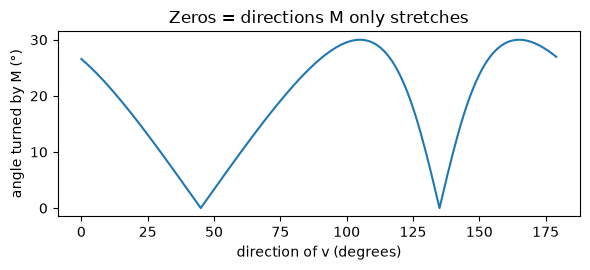

In [74]:
M = np.array([[2.0, 1.0],
              [1.0, 2.0]])
degs = np.arange(0, 180)                                         # v and −v span the same line
V = np.vstack([np.cos(np.radians(degs)), np.sin(np.radians(degs))])   # unit vectors as columns
MV = M @ V
# axis=0: work down each column → one number per column (= per direction)
cos_turn = np.sum(V * MV, axis=0) / np.linalg.norm(MV, axis=0)   # cosine between v and Mv

for k in np.where(np.isclose(np.abs(cos_turn), 1.0))[0]:   # where(cond)[0]: indices where cond is True
    print(f"direction {degs[k]:>3}°: Mv is parallel to v, stretched ×{np.linalg.norm(MV[:, k]):.2f}")

plt.figure(figsize=(6, 2.8))
plt.plot(degs, np.degrees(np.arccos(np.clip(cos_turn, -1, 1))))   # clip into [-1, 1]: rounding can give 1.0000000001, which breaks arccos
plt.xlabel("direction of v (degrees)"); plt.ylabel("angle turned by M (°)")
plt.title("Zeros = directions M only stretches"); plt.tight_layout(); plt.show()

---
## Lesson 6 — Tensors: physics vs ML *(planned)*
Filled in after the lesson. Roadmap: covariant vs contravariant, the transformation-law definition (physics) vs the n-D array view (ML), and why the two communities mean different things by "tensor".
*Sources: Griffiths Ch. 1 · Kolda & Bader, "Tensor Decompositions and Applications", SIAM Review 51(3), 2009 (ML/array view)*

### Pre-lab — what survives a rotation?
Rotate everything with the same 3D rotation $R$: vectors as $Rv$, the matrix as $RAR^\top$ (why — Lesson 6).
▶ **Predict** which lines print `True`.

In [75]:
R = rotation_3d([1, 2, 2], 40)
u, w = rng.normal(size=3), rng.normal(size=3)
A = rng.normal(size=(3, 3))
u_r, w_r, A_r = R @ u, R @ w, R @ A @ R.T

print("components of u unchanged:", np.allclose(u, u_r))
print("‖u‖ unchanged:            ", np.isclose(np.linalg.norm(u), np.linalg.norm(u_r)))
print("u·w unchanged:            ", np.isclose(u @ w, u_r @ w_r))
print("entries of A unchanged:   ", np.allclose(A, A_r))
print("tr(A) unchanged:          ", np.isclose(np.trace(A), np.trace(A_r)))
print("det(A) unchanged:         ", np.isclose(np.linalg.det(A), np.linalg.det(A_r)))
print("\nFor Lesson 6: the components change, yet u and A are 'the same object'. What makes them so?")

components of u unchanged: False
‖u‖ unchanged:             True
u·w unchanged:             True
entries of A unchanged:    False
tr(A) unchanged:           True
det(A) unchanged:          True

For Lesson 6: the components change, yet u and A are 'the same object'. What makes them so?


---
## ★ Mnemonics → NumPy cheat sheet
*Vault: `09 Mnemonics`*

| Mnemonic | NumPy |
|---|---|
| RC — Row Comes first | `M[i, j]`, `M.shape == (rows, cols)`; math $M_{23}$ → `M[1, 2]` |
| Σ is a for-loop | `sum(a[i] for i in range(n))` ≡ `a.sum()` |
| The dot is a full stop | `a @ b` → scalar; `a * b` → same shape (Hadamard) |
| `*` keeps the shape, `@` eats the shared axis | `(m, n) * (m, n) → (m, n)`; `(m, n) @ (n, p) → (m, p)` |
| Number line, not a switch | `np.sign(a @ b)` → +1 / 0 / −1 |
| The hat means length one | `a / np.linalg.norm(a)`, check `np.isclose(np.linalg.norm(a_hat), 1)` |
| Cosine asks "which way?" | `(a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))` |
| Measure, normalize, re-point | `(a @ b) / (a @ a) * a` |
| Columns = where the basis vectors land | `M @ [1, 0] == M[:, 0]`; build with `np.column_stack` |
| Inside out | `A @ B @ v`: `B` acts first |
| Middle numbers kiss and disappear | `(m, n) @ (n, p) → (m, p)`, otherwise `ValueError` |
| Determinant = area scale factor | `abs(np.linalg.det(M))` |
| Sign = handedness | `np.linalg.det(M) < 0` → flipped |
| You can't unscramble an egg | `np.isclose(np.linalg.det(M), 0)` → no inverse |
| Socks and shoes | `(A @ B).T == B.T @ A.T`, `inv(A @ B) == inv(B) @ inv(A)` |
| AᵀA: inner cancels, outer survives | `(A.T @ A).shape == (n, n)` |
| 1-D arrays are orientation-blind | `a.T` is a no-op → `a[:, None]` for a column |
| Repeat it and it's gone | `np.einsum("ik,kj->ij", A, B)` |
| Once free, twice summed, thrice a mistake | count the letters in the spec (`analyze`, Step 4.3) |
| Position doesn't matter, only letters do | `einsum("ij,ij->", A, B) == einsum("ij,ij->", B, A)` |
| Rotate the letters, don't reorder them | `np.trace(A @ B @ C) == np.trace(C @ A @ B)` |
| Trace survives coordinates | `np.trace(inv(P) @ A @ P) == np.trace(A)` |
| Trace = infinitesimal determinant | `det(I + eps*A) ≈ 1 + eps*np.trace(A)` |

### Scoreboard
Counts everything you ran in this session.

In [76]:
groups = defaultdict(lambda: [0, 0, 0])            # ✅ ❌ ⏳
for label, ok in RESULTS.items():
    g = "code" if label.startswith("code:") else label.split(".")[0]
    groups[g][0 if ok else 1 if ok is False else 2] += 1

print(f"{'group':8s}  ✅   ❌   ⏳")
for g in sorted(groups):
    good, bad, todo = groups[g]
    print(f"{g:8s} {good:3d}  {bad:3d}  {todo:3d}")

group     ✅   ❌   ⏳
D1         0    0    1
E0         0    0    4
N1b        0    0    2
N2         0    0    5
P          0    0    3
S1         0    0    4
S2         0    0    6
S3         0    0   17
S4         0    0    9
S5         0    0    6
code       0    0   13
einsum     0    0    8
